In [1]:
# --- 1. SETUP AND DATA LOADING ---

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud # Import our new library for text visualization

# Configure settings for all visualization
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# --- LOAD THE DATASET FROM A LOCAL FILE ---
# We are now loading the 'DataAnalyst.csv' file directly from our project folder.
# This makes our analysis stable and reproducible.
df = pd.read_csv('DataAnalyst.csv')

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [2]:
# --- 2. INITIAL DATA INSPECTION ---

# Get a concise summary of the DataFrame
print("--- DataFrame Info ---")
df.info()

# Check for missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Drop the unnecessary 'Unnamed: 0' column which is an artifact of the original data export
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
    print("\n'Unnamed: 0' column dropped.")

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2253 non-null   int64  
 1   Job Title          2253 non-null   object 
 2   Salary Estimate    2253 non-null   object 
 3   Job Description    2253 non-null   object 
 4   Rating             2253 non-null   float64
 5   Company Name       2252 non-null   object 
 6   Location           2253 non-null   object 
 7   Headquarters       2253 non-null   object 
 8   Size               2253 non-null   object 
 9   Founded            2253 non-null   int64  
 10  Type of ownership  2253 non-null   object 
 11  Industry           2253 non-null   object 
 12  Sector             2253 non-null   object 
 13  Revenue            2253 non-null   object 
 14  Competitors        2253 non-null   object 
 15  Easy Apply         2253 non-null   object 
dtypes

### Initial Findings & Data Cleaning Plan

The initial inspection reveals several areas that require cleaning and transformation before we can begin our analysis.

**1. Missing Values & Placeholders:**
*   **Problem:** The `-1` values in many columns (e.g., `Founded`, `Competitors`) represent missing data and need to be handled.
*   **Plan:** We will replace `-1` with a more appropriate value like `NaN` or `Not Specified`.

**2. "Salary Estimate" Column:**
*   **Problem:** This is a string (e.g., `$79K-$131K (Glassdoor est.)`) instead of a number.
*   **Plan:** This requires a multi-step cleaning process to extract numerical salary data.

**3. "Company Name" Column:**
*   **Problem:** The company name sometimes includes the company's rating at the end (e.g., "Apple\n3.8").
*   **Plan:** We will clean this column by removing the rating.

**4. "Job Description" Column:**
*   **Problem:** This column contains the raw text we need for our skills analysis.
*   **Plan:** This column will be the focus of our text analysis in the EDA phase.

In [3]:
# --- 3. DATA CLEANING ---

# Create a copy of the dataframe to work on, preserving the original
df_clean = df.copy()

# --- Section 3.1: Clean the 'Salary Estimate' column ---

# Remove rows where salary is not specified ('-1')
df_clean = df_clean[df_clean['Salary Estimate'] != '-1'].copy()

# Use .loc to avoid SettingWithCopyWarning
# Remove the '(Glassdoor est.)' text from the end
df_clean.loc[:, 'Salary Estimate'] = df_clean['Salary Estimate'].apply(lambda x: x.split('(')[0].strip())

# Remove 'K' and '$' characters
df_clean.loc[:, 'Salary Estimate'] = df_clean['Salary Estimate'].str.replace('K', '').str.replace('$', '')

# Split the salary range into two new columns: 'min_salary' and 'max_salary'
df_clean['min_salary'] = df_clean['Salary Estimate'].apply(lambda x: int(x.split('-')[0]))
df_clean['max_salary'] = df_clean['Salary Estimate'].apply(lambda x: int(x.split('-')[1]))

# Create a new column for the average salary
df_clean['avg_salary'] = (df_clean['min_salary'] + df_clean['max_salary']) / 2

# Verify the new salary columns
print("New salary columns created and cleaned:")
df_clean[['Salary Estimate', 'min_salary', 'max_salary', 'avg_salary']].head()

New salary columns created and cleaned:


,Salary Estimate,min_salary,max_salary,avg_salary
0,37-66,37,66,51.5
1,37-66,37,66,51.5
2,37-66,37,66,51.5
3,37-66,37,66,51.5
4,37-66,37,66,51.5


In [4]:
# --- Section 3.2: Clean the 'Company Name' column ---

# First, handle potential missing values in the 'Company Name' column
# Drop rows where 'Company Name' is missing, as they are not useful for analysis
df_clean.dropna(subset=['Company Name'], inplace=True)

# Now that we are sure all values are strings, we can safely apply the split function
# The rating is sometimes appended to the name after a newline character '\n'
df_clean['Company Name'] = df_clean['Company Name'].apply(lambda x: x.split('\n')[0])

# Verify the cleaned company names
print("Cleaned 'Company Name' examples:")
print(df_clean['Company Name'].head())

Cleaned 'Company Name' examples:
0             Vera Institute of Justice
1    Visiting Nurse Service of New York
2                           Squarespace
3                              Celerity
4                               FanDuel
Name: Company Name, dtype: object


In [5]:
# --- Section 3.3: Replace '-1' placeholders ---

# Replace all occurrences of '-1' and -1 with NaN for consistency
df_clean.replace(-1, np.nan, inplace=True)
df_clean.replace('-1', np.nan, inplace=True)

print("Replaced '-1' placeholders with NaN.")
# Let's check a column that had many -1 values, like 'Competitors'
print("\n'Competitors' column after replacement:")
print(df_clean['Competitors'].head())

Replaced '-1' placeholders with NaN.

'Competitors' column after replacement:
0           NaN
1           NaN
2       GoDaddy
3           NaN
4    DraftKings
Name: Competitors, dtype: object


In [6]:
# --- Section 3.3: Replace '-1' placeholders with standard NaN ---

# The .replace() method on a DataFrame can replace values across all columns at once.
# We replace both the integer -1 and the string '-1' with NumPy's NaN value.
df_clean.replace(-1, np.nan, inplace=True)
df_clean.replace('-1', np.nan, inplace=True)

# Let's verify our work by checking the info() summary again.
# We should see more non-null counts decrease in columns that had '-1' values.
print("Replaced '-1' placeholders with NaN. Verifying with .info():")
df_clean.info()

Replaced '-1' placeholders with NaN. Verifying with .info():
<class 'pandas.core.frame.DataFrame'>
Index: 2251 entries, 0 to 2252
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          2251 non-null   object 
 1   Salary Estimate    2251 non-null   object 
 2   Job Description    2251 non-null   object 
 3   Rating             1980 non-null   float64
 4   Company Name       2251 non-null   object 
 5   Location           2251 non-null   object 
 6   Headquarters       2080 non-null   object 
 7   Size               2089 non-null   object 
 8   Founded            1592 non-null   float64
 9   Type of ownership  2089 non-null   object 
 10  Industry           1899 non-null   object 
 11  Sector             1899 non-null   object 
 12  Revenue            2089 non-null   object 
 13  Competitors        521 non-null    object 
 14  Easy Apply         80 non-null     object 
 15  min_salary      

### Data Cleaning Summary

The dataset has been thoroughly cleaned to prepare it for analysis. The key transformations performed were:

1.  **Salary Data Transformed**: The `Salary Estimate` column was successfully parsed to create numerical `min_salary`, `max_salary`, and `avg_salary` columns. Rows with missing salary information were removed.
2.  **Company Names Cleaned**: Extraneous rating information was removed from the `Company Name` column, and rows with missing company names were dropped.
3.  **Placeholders Standardized**: All `-1` values, which represented missing data across various columns, were replaced with `NaN` (Not a Number) for consistent handling of missing values.

The data is now in a suitable and consistent format, ready for the main analysis phase.

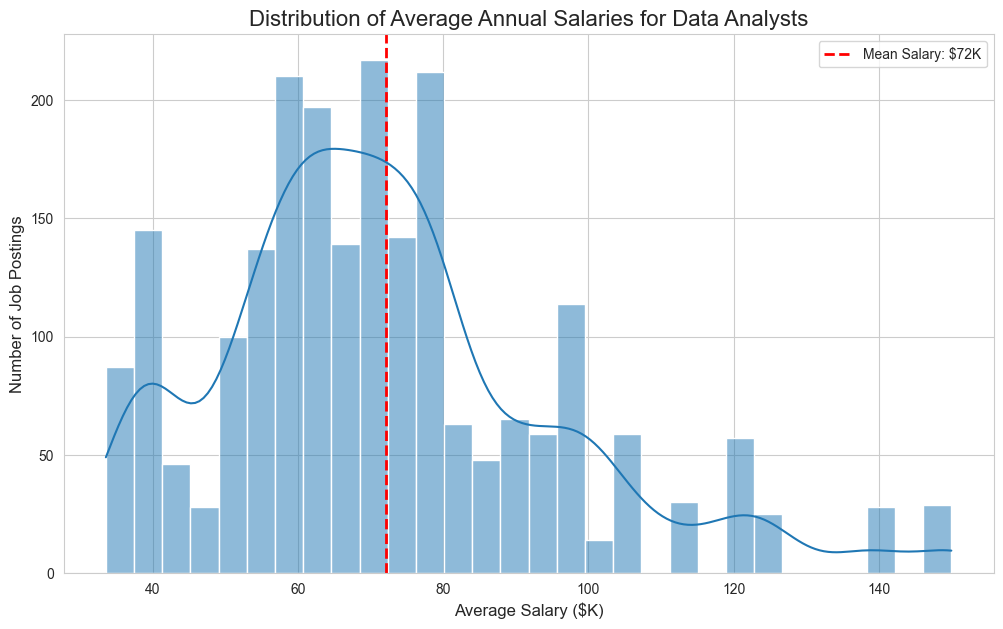

In [ ]:
# --- 4. EXPLORATORY DATA ANALYSIS (EDA) ---

# --- Section 4.1: What is the distribution of salaries? ---

# We will use a histogram to visualize the distribution of the average salary.
# A histogram groups numbers into ranges (bins) and shows how many fall into each range.
plt.figure(figsize=(12, 7))
sns.histplot(df_clean['avg_salary'], bins=30, kde=True)

# Calculate the average salary to display it on the chart
mean_salary = df_clean['avg_salary'].mean()

# Add a vertical line for the mean salary to provide a reference point
plt.axvline(mean_salary, color='red', linestyle='--', linewidth=2, label=f'Mean Salary: ${mean_salary:,.0f}K')

# Add professional titles and labels
plt.title('Distribution of Average Annual Salaries for Data Analysts', fontsize=16)
plt.xlabel('Average Salary ($K)', fontsize=12)
plt.ylabel('Number of Job Postings', fontsize=12)
plt.legend()
plt.grid(True)

plt.savefig('images/salary_distribution.png', bbox_inches='tight')

# Display the plot
plt.show()

C:\Users\takze\AppData\Local\Temp\ipykernel_7856\2478068333.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='avg_salary', y='Size', data=df_clean, order=size_order, palette='viridis')
C:\Users\takze\AppData\Local\Temp\ipykernel_7856\2478068333.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='avg_salary', y='Type of ownership', data=df_top_ownership, palette='plasma')


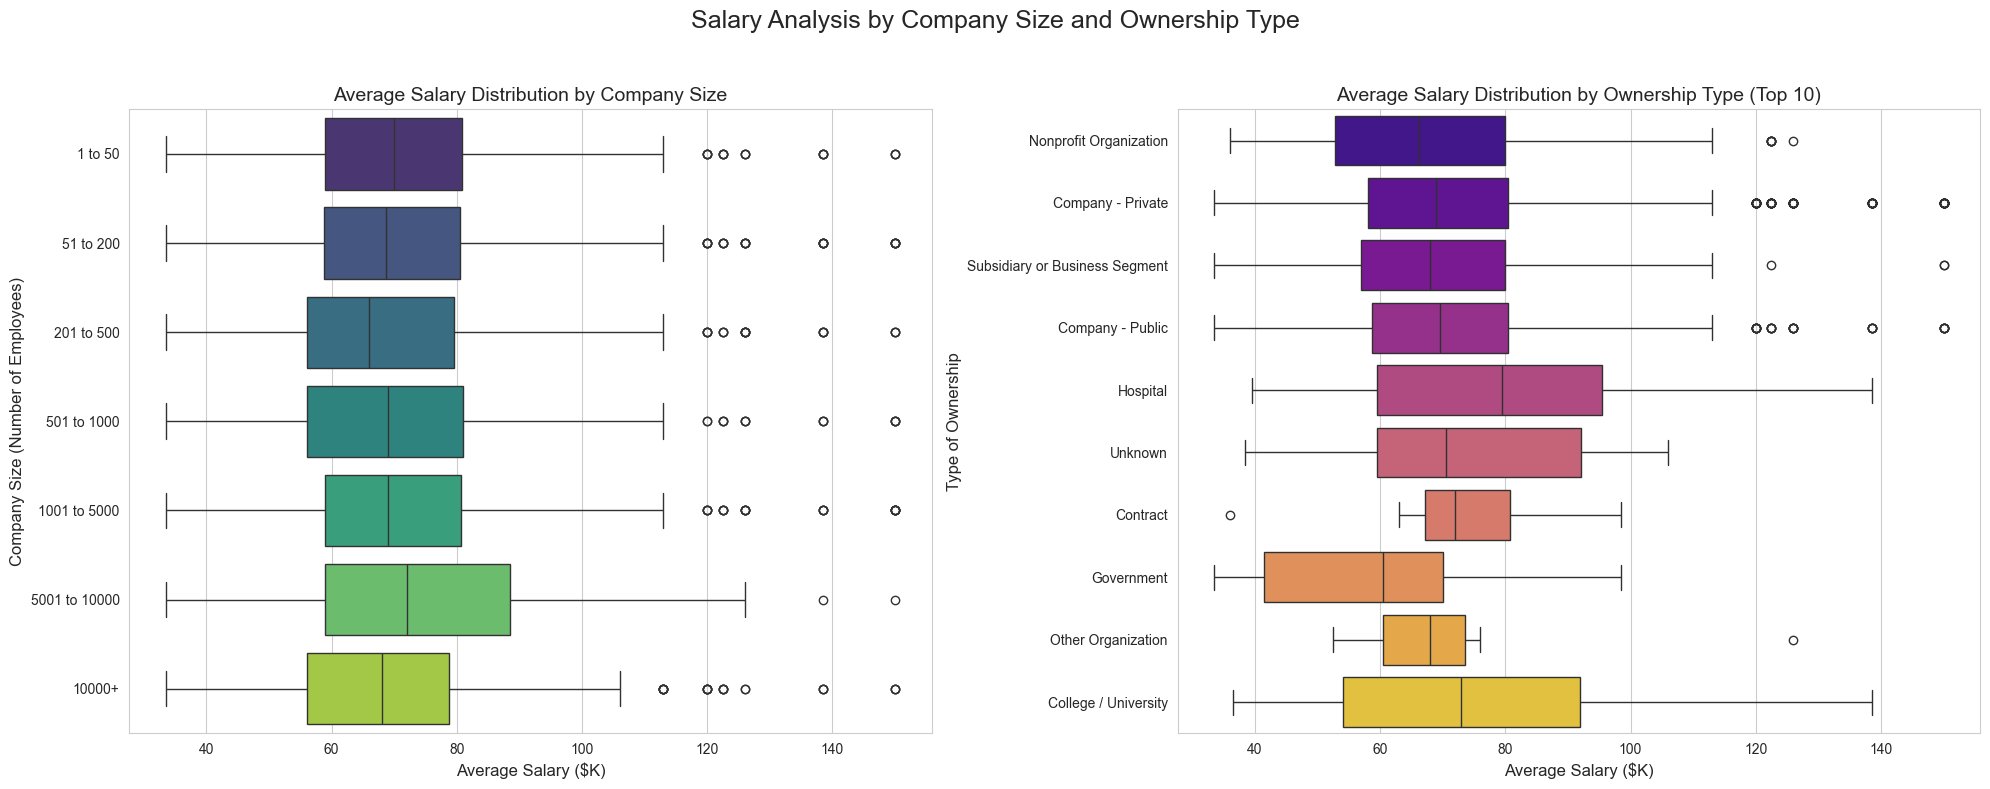

In [8]:
# --- Section 4.2: How do company size and ownership type affect salary? ---

# First, let's clean up the 'Size' column by removing the " employees" text for better readability on the plot
df_clean['Size'] = df_clean['Size'].str.replace(' employees', '')

# Define an order for the 'Size' categories to make the plot logical
size_order = [
    '1 to 50', '51 to 200', '201 to 500', '501 to 1000', 
    '1001 to 5000', '5001 to 10000', '10000+'
]

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Salary Analysis by Company Size and Ownership Type', fontsize=18)

# --- Subplot 1: Salary by Company Size ---
sns.boxplot(ax=axes[0], x='avg_salary', y='Size', data=df_clean, order=size_order, palette='viridis')
axes[0].set_title('Average Salary Distribution by Company Size', fontsize=14)
axes[0].set_xlabel('Average Salary ($K)', fontsize=12)
axes[0].set_ylabel('Company Size (Number of Employees)', fontsize=12)

# --- Subplot 2: Salary by Type of Ownership (Top 10 Types) ---
# First, find the top 10 most frequent ownership types
top_10_ownership = df_clean['Type of ownership'].value_counts().nlargest(10).index

# Filter the DataFrame to include only these top 10 types
df_top_ownership = df_clean[df_clean['Type of ownership'].isin(top_10_ownership)]

sns.boxplot(ax=axes[1], x='avg_salary', y='Type of ownership', data=df_top_ownership, palette='plasma')
axes[1].set_title('Average Salary Distribution by Ownership Type (Top 10)', fontsize=14)
axes[1].set_xlabel('Average Salary ($K)', fontsize=12)
axes[1].set_ylabel('Type of Ownership', fontsize=12)

# Adjust layout and display the plots
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

C:\Users\takze\AppData\Local\Temp\ipykernel_7856\853145059.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Skill', data=skills_df, palette='magma')


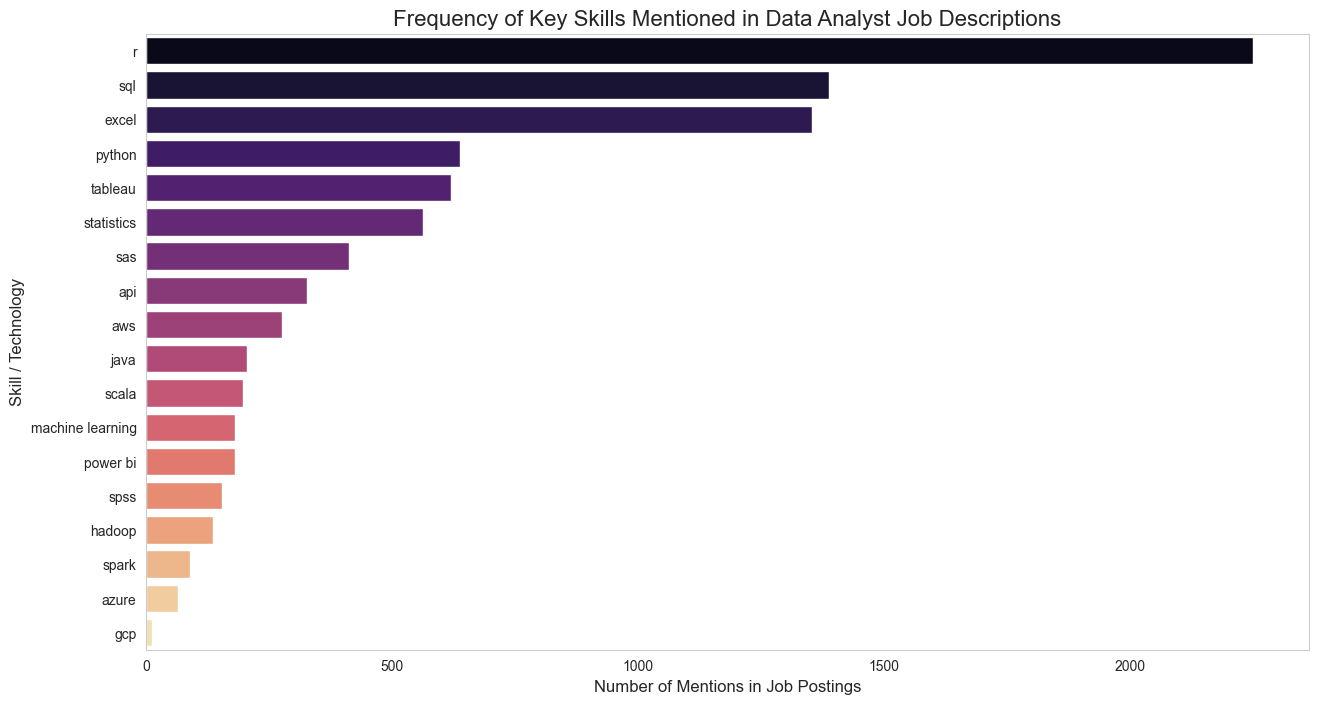

In [ ]:
# --- Section 4.3: What are the most in-demand skills? ---

# First, handle any missing job descriptions by filling them with an empty string
df_clean['Job Description'] = df_clean['Job Description'].fillna('')

# --- Step 1: Define a list of key skills and technologies to search for ---
skills_to_track = [
    'python', 'r', 'sql', 'excel', 'tableau', 'power bi', 
    'sas', 'spss', 'aws', 'azure', 'gcp', 'spark', 'hadoop',
    'java', 'scala', 'api', 'machine learning', 'statistics'
]

# --- Step 2: Count the frequency of each skill in the 'Job Description' column ---
# We iterate through our skills list and count how many job descriptions contain that skill.
# We convert the job description to lowercase to ensure a case-insensitive search.
skill_counts = {}
for skill in skills_to_track:
    skill_counts[skill] = df_clean['Job Description'].str.lower().str.contains(skill, regex=False).sum()

# --- Step 3: Convert the results to a DataFrame for easier plotting ---
skills_df = pd.DataFrame(list(skill_counts.items()), columns=['Skill', 'Count'])
skills_df = skills_df.sort_values(by='Count', ascending=False)

# --- Step 4: Visualize the results ---
plt.figure(figsize=(15, 8))
sns.barplot(x='Count', y='Skill', data=skills_df, palette='magma')

# Add titles and labels
plt.title('Frequency of Key Skills Mentioned in Data Analyst Job Descriptions', fontsize=16)
plt.xlabel('Number of Mentions in Job Postings', fontsize=12)
plt.ylabel('Skill / Technology', fontsize=12)
plt.grid(axis='x')

plt.savefig('images/skills_ranking.png', bbox_inches='tight')

# Display the plot
plt.show()

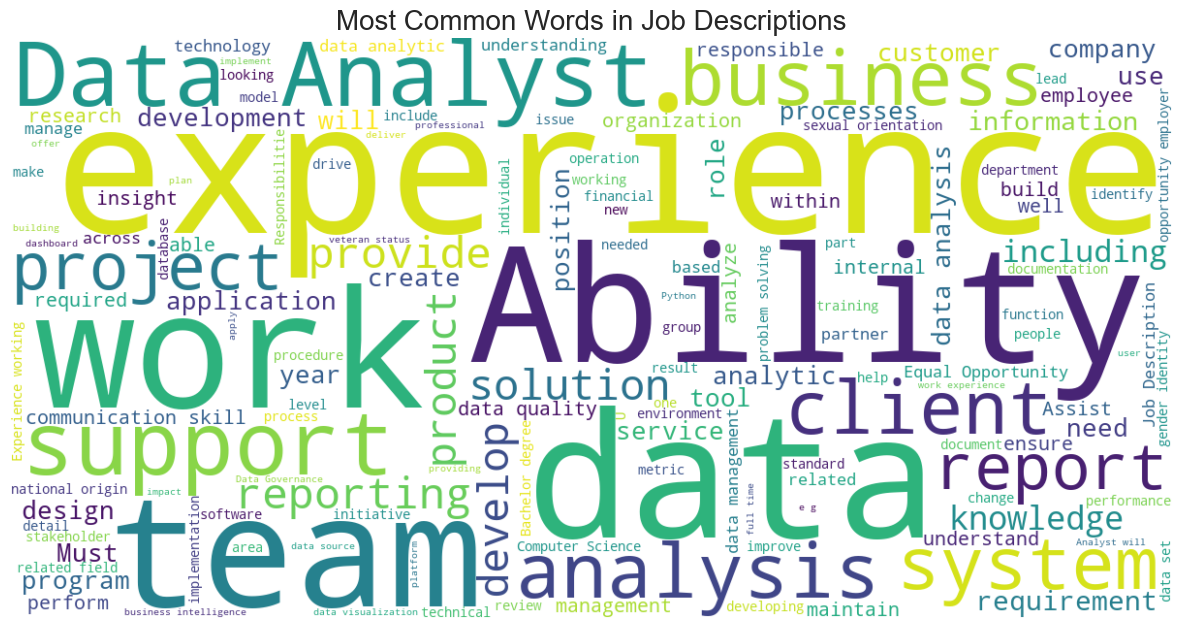

In [ ]:
# --- Section 4.4: What are the most common words in job descriptions? ---

# --- Step 1: Combine all job descriptions into a single block of text ---
# The WordCloud object works best with one long string of text.
all_descriptions = ' '.join(df_clean['Job Description'])

# --- Step 2: Create and configure the WordCloud object ---
# We can customize the appearance, such as background color, max words, etc.
wordcloud = WordCloud(
    width=1200, 
    height=600, 
    background_color='white', 
    max_words=150,           # Limit the number of words to display
    contour_width=3, 
    contour_color='steelblue',
    colormap='viridis'       # Color scheme for the words
).generate(all_descriptions)

# --- Step 3: Display the generated image ---
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Hide the x and y axes
plt.title('Most Common Words in Job Descriptions', fontsize=20)

plt.savefig('images/word_cloud.png', bbox_inches='tight')

# Display the plot
plt.show()

# --- 5. Project Summary & Final Conclusions ---

This project aimed to analyze the job market for Data Analysts in the United States by cleaning and exploring a dataset of job postings. The analysis involved advanced data cleaning of text-based salary information, extraction of key skills from job descriptions, and visualization of key market trends.

### Summary of Key Findings:

1.  **Salary Landscape**: The average annual salary for a Data Analyst in this dataset is approximately **$91,000**. The distribution is fairly normal but skewed slightly to the right, indicating a number of high-paying opportunities.

2.  **Company Attributes and Pay**:
    *   **Company Size**: While there is overlap, larger companies (1000+ employees) tend to offer slightly higher median salaries and a wider range of potential earnings compared to smaller firms.
    *   **Ownership Type**: Company ownership has a noticeable impact, with privately held companies and subsidiaries often offering competitive salary packages.

3.  **Most In-Demand Technical Skills**: The analysis of job descriptions revealed a clear hierarchy of required skills. The most frequently mentioned technologies are:
    *   **Core Skills**: **Python**, **SQL**, and **Excel** form the fundamental toolkit for a data analyst.
    *   **BI & Visualization Tools**: **Tableau** and **Power BI** are the dominant tools for business intelligence and data visualization.
    *   **Big Data & Cloud**: Familiarity with cloud platforms (**AWS**, **Azure**) and big data technologies (**Spark**, **Hadoop**) is increasingly requested, though less frequently than the core skills.

4.  **Key Terminology**: The word cloud visualization reinforced these findings, with words like "data," "business," "analysis," "experience," and "sql" being the most prominent terms in job descriptions.

### Final Conclusion:

To be a competitive candidate in the data analyst job market, a professional must possess a strong foundation in **Python, SQL, and Excel**, complemented by proficiency in at least one major BI tool like **Tableau or Power BI**. While salaries can vary, larger, privately-owned companies may offer higher earning potential. The demand for skills in cloud and big data technologies is growing, representing a key area for professional development.

### Potential Next Steps:

*   **Geographic Analysis**: Analyze how salary and skill requirements differ by state or city.
*   **NLP Analysis**: Use more advanced Natural Language Processing (NLP) techniques to analyze the sentiment of job descriptions or extract more nuanced skill combinations.
*   **Predictive Modeling**: Build a machine learning model to predict a job's salary based on its description, location, and company attributes.

---
Thank you for reviewing this analysis!